<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/saft_vr_mie_from_fundamental_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From quantum interactions to SAFT-VR Mie parameters and NeqSim

This executable proposal connects four model scales in one reproducible workflow:

1. **PySCF** calculates an *ab initio* argon-dimer interaction curve.
2. **SciPy** maps the interaction energies to Mie parameters without fitting bulk PVT data.
3. A transparent **Metropolis molecular simulation** and **teqp** independently test the pair model and SAFT-VR Mie equation.
4. **NeqSim** receives the parameters and propagates them to thermodynamic and compressor calculations.

The live quantum calculation uses CCSD(T)/aug-cc-pVDZ with counterpoise correction. It is deliberately small enough for a free Colab runtime. Its result is a **teaching-quality bottom-up estimate**, not a metrology-quality argon potential. A second route uses the literature-grade methane mapping of Walker *et al.* to demonstrate the intended engineering hand-off.


## 1. Scope, deliverables, and decision gates

| Work package | Executed deliverable | Decision gate |
|---|---|---|
| Electronic structure | Counterpoise-corrected Ar$_2$ energy scan | Repulsive wall, attractive well, and long-range decay are present |
| Coarse graining | $\sigma$, $\epsilon/k_B$, $\lambda_r$ with $\lambda_a=6$ | Fit is numerically stable and uncertainty is reported |
| Statistical mechanics | Pair-potential $B_2(T)$ and NVT Monte Carlo | Independent physical trends are sensible |
| EOS validation | Critical points and $Z(P)$ from teqp | NeqSim and teqp agree for identical parameters |
| Process use | NeqSim methane compression case | Parameter provenance reaches an engineering KPI |
| Scale-up | FEASST-ready parameter block | Production VLE/mixture simulations have a defined next step |

**Success does not mean that a small-basis dimer calculation reproduces experiment.** Success means that every transformation is explicit, unit-audited, independently checked, and honest about missing physics.


## 2. Open-source stack

| Layer | Software used here | Role |
|---|---|---|
| Quantum chemistry | [PySCF](https://pyscf.org/) | CCSD(T) dimer energies from first principles |
| Mapping and uncertainty | [SciPy](https://scipy.org/) | Nonlinear least squares, quadrature, roots, and bootstrap |
| Molecular simulation | NumPy reference MC; [FEASST](https://pages.nist.gov/feasst/) hand-off | Transparent NVT check here; scalable Gibbs/flat-histogram MC next |
| Independent SAFT implementation | [teqp](https://teqp.readthedocs.io/en/latest/models/SAFT-VR-Mie.html) | Critical point, virial, and pressure calculations |
| Engineering thermodynamics | [NeqSim](https://github.com/equinor/neqsim) | SAFT-VR Mie properties and process equipment |

PySCF, SciPy, FEASST, teqp, and NeqSim are all open source. FEASST is the recommended production simulator when finite-size analysis, Gibbs-ensemble VLE, mixtures, or advanced sampling are required. The short NumPy MC in this notebook keeps the verification path visible and fast.


## 3. Clean Colab setup

A fresh Colab runtime installs exact versions of the three specialist packages. NumPy, SciPy, pandas, and Matplotlib are supplied by Colab. No repository checkout, local JAR, editable installation, or runtime restart is required.


In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys


required = {
    "neqsim": "3.16.0",
    "teqp": "0.23.2",
    "pyscf": "2.14.0",
}

install_specs = []
for package, version in required.items():
    installed = (
        importlib.metadata.version(package)
        if importlib.util.find_spec(package) is not None
        else None
    )
    if installed != version:
        install_specs.append(f"{package}=={version}")

if install_specs:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-cache-dir",
            "--disable-pip-version-check",
            *install_specs,
        ]
    )

print("Specialist packages are ready:", required)


Specialist packages are ready: {'neqsim': '3.16.0', 'teqp': '0.23.2', 'pyscf': '2.14.0'}


## 4. Imports and runtime provenance

The constants below keep energy and length conversions explicit. Pair energies are reported as $u/k_B$ in kelvin, the convention used by SAFT-VR Mie parameter tables.


In [2]:
import importlib.metadata
import json
import math
import os
import platform
import subprocess
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import teqp
from IPython.display import display
from pyscf import cc, gto, lib, scf
from scipy.integrate import quad
from scipy.optimize import brentq, least_squares

from neqsim import jneqsim


R = 8.31446261815324  # J mol^-1 K^-1
N_A = 6.02214076e23  # mol^-1
HARTREE_TO_K = 315775.02480407
ANGSTROM_TO_M = 1.0e-10
RNG = np.random.default_rng(20260726)

# Some sandboxed validation runtimes hide /proc/<pid>/statm.
# Colab has it; this fallback changes only PySCF's memory estimate.
if not os.path.exists(f"/proc/{os.getpid()}/statm"):
    lib.current_memory = lambda: (0.0, 0.0)
lib.num_threads(min(2, os.cpu_count() or 1))

runtime = {
    "python": platform.python_version(),
    "java": subprocess.run(
        ["java", "-version"],
        check=True,
        capture_output=True,
        text=True,
    ).stderr.splitlines()[0],
    **{
        package: importlib.metadata.version(package)
        for package in required
    },
}
display(pd.Series(runtime, name="version"))


python                                 3.12.13
java      openjdk version "17.0.19" 2026-04-21
neqsim                                  3.16.0
teqp                                    0.23.2
pyscf                                   2.14.0
Name: version, dtype: str

## 5. The Mie potential and the parameters to be mapped

SAFT-VR Mie uses the segment pair potential

$$
u(r)=C\epsilon\left[\left(\frac{\sigma}{r}\right)^{\lambda_r}
-\left(\frac{\sigma}{r}\right)^{\lambda_a}\right]
$$

with

$$
C=\frac{\lambda_r}{\lambda_r-\lambda_a}
\left(\frac{\lambda_r}{\lambda_a}\right)^{
\lambda_a/(\lambda_r-\lambda_a)}.
$$

Here $\sigma$ is the zero-crossing distance, $\epsilon$ is the well depth, and $\lambda_r$ and $\lambda_a$ control repulsion and attraction. For a monatomic dispersion fluid, $m=1$ and the asymptotic $r^{-6}$ form motivates $\lambda_a=6$. The remaining three parameters can be mapped from an interaction curve.

For chain molecules, $m$ is an additional coarse-graining decision. Association energies, association volumes, molecular shape, many-body interactions, and unlike-pair rules require further information; they cannot be inferred from one isotropic dimer curve.


In [3]:
def mie_constant(lambda_r, lambda_a=6.0):
    return (
        lambda_r
        / (lambda_r - lambda_a)
        * (lambda_r / lambda_a)
        ** (lambda_a / (lambda_r - lambda_a))
    )


def mie_u_over_k(r_angstrom, sigma_angstrom, epsilon_over_k,
                 lambda_r, lambda_a=6.0):
    r = np.asarray(r_angstrom, dtype=float)
    c_mie = mie_constant(lambda_r, lambda_a)
    return c_mie * epsilon_over_k * (
        (sigma_angstrom / r) ** lambda_r
        - (sigma_angstrom / r) ** lambda_a
    )


def mie_minimum(sigma_angstrom, lambda_r, lambda_a=6.0):
    return sigma_angstrom * (
        lambda_r / lambda_a
    ) ** (1.0 / (lambda_r - lambda_a))


methane_mapped = {
    "name": "Methane, potential-mapped (Walker et al.)",
    "m": 1.0,
    "sigma_angstrom": 3.7592,
    "epsilon_over_k": 170.13,
    "lambda_r": 14.440,
    "lambda_a": 6.0,
}
methane_neqsim = {
    "name": "Methane, NeqSim/Lafitte parameter set",
    "m": 1.0,
    "sigma_angstrom": 3.7412,
    "epsilon_over_k": 153.36,
    "lambda_r": 12.65,
    "lambda_a": 6.0,
}
argon_lafitte = {
    "name": "Argon, established SAFT-VR Mie set",
    "m": 1.0,
    "sigma_angstrom": 3.4016,
    "epsilon_over_k": 117.84,
    "lambda_r": 12.085,
    "lambda_a": 6.0,
}

for parameters in (methane_mapped, methane_neqsim, argon_lafitte):
    r_min = mie_minimum(
        parameters["sigma_angstrom"],
        parameters["lambda_r"],
        parameters["lambda_a"],
    )
    u_min = mie_u_over_k(
        r_min,
        parameters["sigma_angstrom"],
        parameters["epsilon_over_k"],
        parameters["lambda_r"],
        parameters["lambda_a"],
    )
    assert abs(u_min + parameters["epsilon_over_k"]) < 1.0e-9

parameter_table = pd.DataFrame(
    [
        {
            "Parameter set": p["name"],
            "m [-]": p["m"],
            "sigma [Å]": p["sigma_angstrom"],
            "epsilon/kB [K]": p["epsilon_over_k"],
            "lambda_r [-]": p["lambda_r"],
            "lambda_a [-]": p["lambda_a"],
        }
        for p in (methane_mapped, methane_neqsim, argon_lafitte)
    ]
)
display(parameter_table)


,Parameter set,m [-],sigma [Å],epsilon/kB [K],lambda_r [-],lambda_a [-]
0,"Methane, potential-mapped (Walker et al.)",1.0,3.7592,170.13,14.440,6.0
1,"Methane, NeqSim/Lafitte parameter set",1.0,3.7412,153.36,12.650,6.0
2,"Argon, established SAFT-VR Mie set",1.0,3.4016,117.84,12.085,6.0


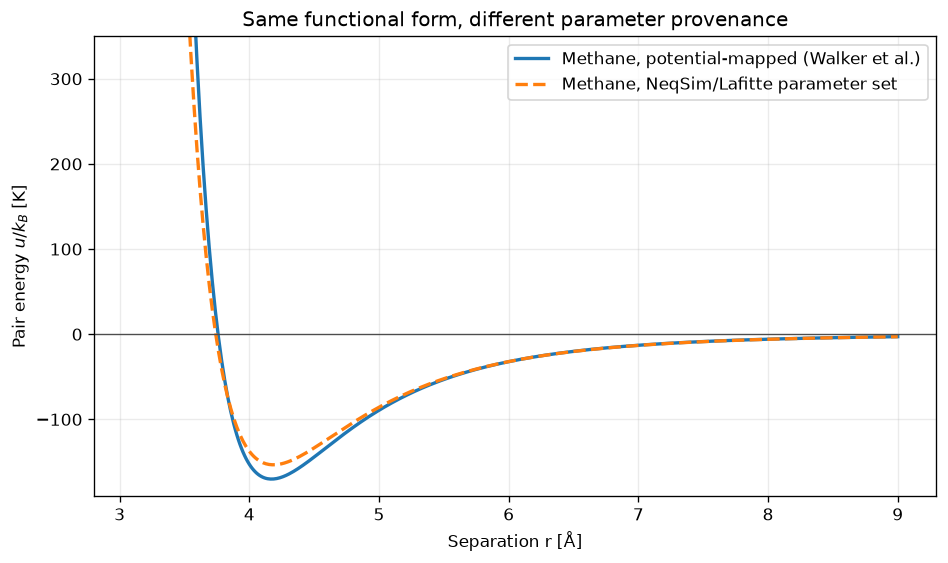

In [4]:
r_plot = np.linspace(3.1, 9.0, 500)
fig, ax = plt.subplots(figsize=(8, 4.8))
for parameters, style in [
    (methane_mapped, "-"),
    (methane_neqsim, "--"),
]:
    ax.plot(
        r_plot,
        mie_u_over_k(
            r_plot,
            parameters["sigma_angstrom"],
            parameters["epsilon_over_k"],
            parameters["lambda_r"],
            parameters["lambda_a"],
        ),
        style,
        linewidth=2,
        label=parameters["name"],
    )
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Separation r [Å]",
    ylabel=r"Pair energy $u/k_B$ [K]",
    ylim=(-190, 350),
    title="Same functional form, different parameter provenance",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Live fundamental calculation: counterpoise-corrected Ar$_2$

The interaction energy is evaluated with the Boys-Bernardi counterpoise construction

$$
\Delta E_{\mathrm{int}}(r)
=E_{\mathrm{Ar_2}}^{AB}(r)
-E_{\mathrm{Ar}}^{AB}(r)
-E_{\mathrm{Ar}}^{AB}(r).
$$

The superscript $AB$ means that both monomer basis sets are present; one atom is a ghost center in each monomer calculation. CCSD(T) captures pair correlation, but aug-cc-pVDZ is far from the complete-basis limit for weak dispersion. The scan therefore demonstrates **how** to obtain parameters and simultaneously exposes the accuracy gate.


In [5]:
def ccsdt_total_energy(atom_specification):
    molecule = gto.M(
        atom=atom_specification,
        basis="aug-cc-pvdz",
        unit="Angstrom",
        charge=0,
        spin=0,
        verbose=0,
    )
    mean_field = scf.RHF(molecule)
    mean_field.conv_tol = 1.0e-10
    mean_field.kernel()
    coupled_cluster = cc.CCSD(mean_field)
    coupled_cluster.conv_tol = 1.0e-8
    coupled_cluster.kernel()
    triples = coupled_cluster.ccsd_t()
    return (
        float(mean_field.e_tot)
        + float(coupled_cluster.e_corr)
        + float(triples)
    )


ar_distances = np.array(
    [3.0, 3.3, 3.6, 3.9, 4.2, 4.6, 5.0, 5.7, 7.0]
)
ar_interaction_k = []
scan_start = time.perf_counter()

for distance in ar_distances:
    dimer_energy = ccsdt_total_energy(
        f"Ar 0 0 0; Ar 0 0 {distance}"
    )
    monomer_energy = ccsdt_total_energy(
        f"Ar 0 0 0; ghost-Ar 0 0 {distance}"
    )
    interaction = (
        dimer_energy - 2.0 * monomer_energy
    ) * HARTREE_TO_K
    ar_interaction_k.append(interaction)
    print(
        f"r = {distance:4.1f} Å, "
        f"Delta E/kB = {interaction:9.3f} K"
    )

ar_interaction_k = np.asarray(ar_interaction_k)
scan_seconds = time.perf_counter() - scan_start
print(f"Completed {len(ar_distances)} points in {scan_seconds:.1f} s")


r =  3.0 Å, Delta E/kB =  1510.436 K
r =  3.3 Å, Delta E/kB =   352.666 K
r =  3.6 Å, Delta E/kB =    18.082 K
r =  3.9 Å, Delta E/kB =   -57.363 K
r =  4.2 Å, Delta E/kB =   -60.522 K
r =  4.6 Å, Delta E/kB =   -43.534 K
r =  5.0 Å, Delta E/kB =   -28.238 K
r =  5.7 Å, Delta E/kB =   -13.038 K
r =  7.0 Å, Delta E/kB =    -3.678 K
Completed 9 points in 46.8 s


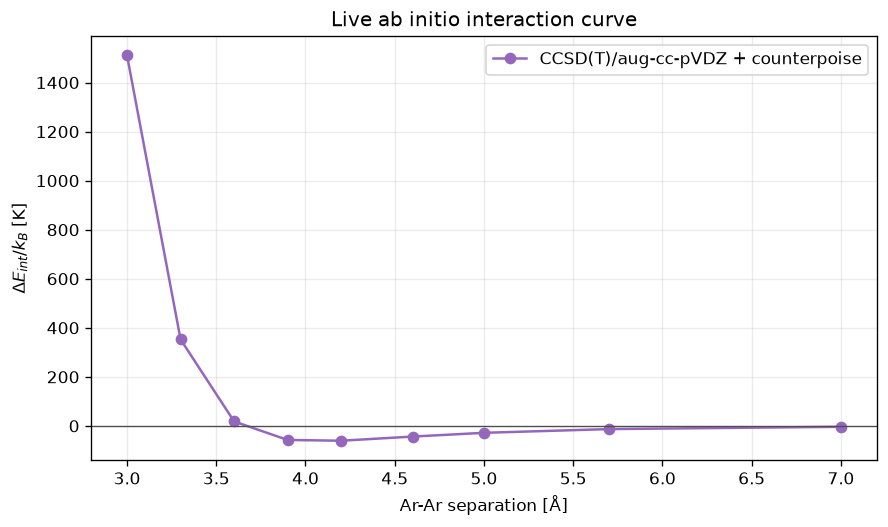

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    ar_distances,
    ar_interaction_k,
    "o-",
    color="tab:purple",
    label="CCSD(T)/aug-cc-pVDZ + counterpoise",
)
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Ar-Ar separation [Å]",
    ylabel=r"$\Delta E_{int}/k_B$ [K]",
    title="Live ab initio interaction curve",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

assert ar_interaction_k[0] > 0.0
assert np.min(ar_interaction_k) < 0.0
assert abs(ar_interaction_k[-1]) < abs(np.min(ar_interaction_k))


## 7. Map the quantum curve to Mie parameters

We hold $\lambda_a=6$ and $m=1$, then determine
$\theta=(\sigma,\epsilon/k_B,\lambda_r)$ from weighted nonlinear least squares:

$$
\hat{\theta}=\arg\min_{\theta}
\sum_i\left[
\frac{u_{\mathrm{Mie}}(r_i;\theta)-u_i^{\mathrm{QM}}}
{10\ \mathrm{K}+0.02|u_i^{\mathrm{QM}}|}
\right]^2.
$$

The scaling prevents the large repulsive energies from erasing information about the well. This is a **potential fit**, not a fit to vapor pressure, density, or critical data.


In [7]:
fit_scale = 10.0 + 0.02 * np.abs(ar_interaction_k)


def weighted_residual(parameters, distances, energies):
    sigma, epsilon_over_k, lambda_r = parameters
    prediction = mie_u_over_k(
        distances, sigma, epsilon_over_k, lambda_r, 6.0
    )
    return (prediction - energies) / (
        10.0 + 0.02 * np.abs(energies)
    )


fit = least_squares(
    weighted_residual,
    x0=np.array([3.6, 80.0, 12.0]),
    bounds=(
        np.array([2.5, 10.0, 7.0]),
        np.array([4.5, 500.0, 40.0]),
    ),
    args=(ar_distances, ar_interaction_k),
)
sigma_fit, epsilon_fit, lambda_r_fit = fit.x
ar_fundamental = {
    "name": "Argon, live CCSD(T)/small-basis map",
    "m": 1.0,
    "sigma_angstrom": sigma_fit,
    "epsilon_over_k": epsilon_fit,
    "lambda_r": lambda_r_fit,
    "lambda_a": 6.0,
}
ar_prediction = mie_u_over_k(
    ar_distances, sigma_fit, epsilon_fit, lambda_r_fit, 6.0
)
ar_rmse = float(
    np.sqrt(np.mean((ar_prediction - ar_interaction_k) ** 2))
)

degrees_of_freedom = len(ar_distances) - len(fit.x)
residual_variance = 2.0 * fit.cost / degrees_of_freedom
covariance = residual_variance * np.linalg.inv(
    fit.jac.T @ fit.jac
)
standard_errors = np.sqrt(np.diag(covariance))

mapped_table = pd.DataFrame(
    {
        "Parameter": [
            "sigma [Å]",
            "epsilon/kB [K]",
            "lambda_r [-]",
        ],
        "Estimate": fit.x,
        "Local standard error": standard_errors,
    }
)
display(mapped_table)
print(f"Unweighted energy RMSE: {ar_rmse:.2f} K")


Unweighted energy RMSE: 6.78 K


,Parameter,Estimate,Local standard error
0,sigma [Å],3.653239,0.009366
1,epsilon/kB [K],61.515501,3.179467
2,lambda_r [-],10.959536,0.286796


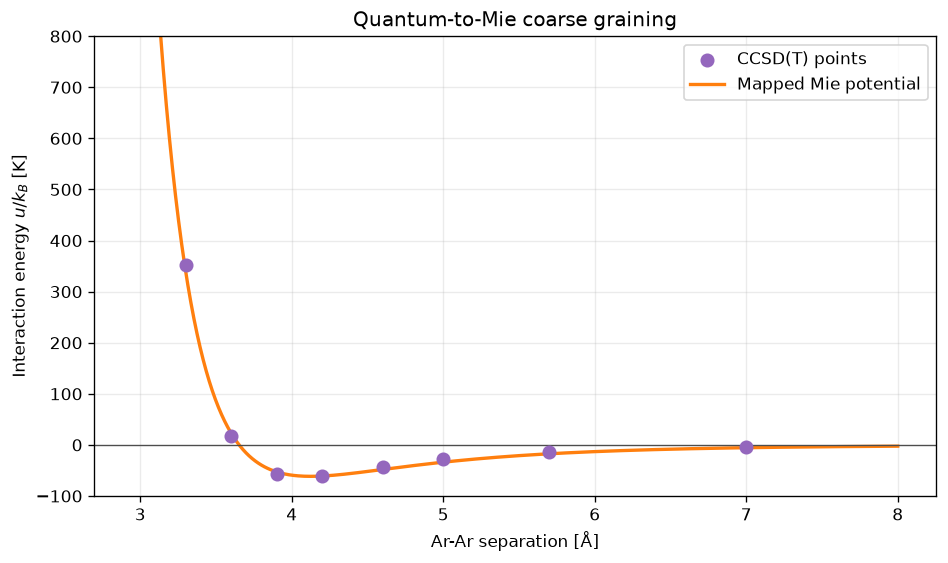

In [8]:
r_fit_plot = np.linspace(2.95, 8.0, 500)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(
    ar_distances,
    ar_interaction_k,
    s=55,
    color="tab:purple",
    label="CCSD(T) points",
    zorder=3,
)
ax.plot(
    r_fit_plot,
    mie_u_over_k(
        r_fit_plot,
        sigma_fit,
        epsilon_fit,
        lambda_r_fit,
        6.0,
    ),
    color="tab:orange",
    linewidth=2,
    label="Mapped Mie potential",
)
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Ar-Ar separation [Å]",
    ylabel=r"Interaction energy $u/k_B$ [K]",
    ylim=(-100, 800),
    title="Quantum-to-Mie coarse graining",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Accuracy interpretation

The live map isolates the numerical workflow, but it omits complete-basis extrapolation, core-valence correlation, relativistic corrections, and non-additive three-body dispersion. Those omissions are systematic and are **not** represented by the local fit covariance.

A research workflow should replace the quick scan with CCSD(T)/CBS or a validated many-body potential, add denser sampling around the zero crossing and minimum, and quantify electronic-structure/model-form uncertainty. Walker *et al.* further show how Barker-Henderson diameter and van der Waals integrals can be used in the mapping, including Axilrod-Teller and Feynman-Hibbs corrections where needed.


## 8. Statistical-mechanical checkpoint: the second virial coefficient

Directly from a pair potential,

$$
B_2(T)=-2\pi N_A\int_0^\infty
\left[\exp\left(-\frac{u(r)}{k_BT}\right)-1\right]r^2\,dr.
$$

This is the cleanest bridge between a fundamental pair potential and low-density thermodynamics. We compare the direct pair integral with teqp's SAFT-VR Mie virial prediction. They need not be identical because the analytical EOS contains approximations.


In [9]:
def pair_second_virial(T, parameters):
    sigma_m = parameters["sigma_angstrom"] * ANGSTROM_TO_M
    epsilon_over_k = parameters["epsilon_over_k"]
    lambda_r = parameters["lambda_r"]
    lambda_a = parameters["lambda_a"]
    c_mie = mie_constant(lambda_r, lambda_a)

    def dimensionless_integrand(x):
        if x < 0.04:
            return -x * x
        exponent = -c_mie * epsilon_over_k / T * (
            x ** (-lambda_r) - x ** (-lambda_a)
        )
        return np.expm1(exponent) * x * x

    integral, error = quad(
        dimensionless_integrand,
        0.0,
        50.0,
        epsabs=1.0e-10,
        epsrel=1.0e-9,
        limit=400,
    )
    return -2.0 * np.pi * N_A * sigma_m**3 * integral, error


def make_teqp_model(parameters):
    coefficient = {
        "name": parameters["name"],
        "BibTeXKey": "notebook-provenance",
        "m": parameters["m"],
        "epsilon_over_k": parameters["epsilon_over_k"],
        "sigma_m": parameters["sigma_angstrom"] * ANGSTROM_TO_M,
        "lambda_r": parameters["lambda_r"],
        "lambda_a": parameters["lambda_a"],
    }
    return teqp.make_model(
        {
            "kind": "SAFT-VR-Mie",
            "model": {"coeffs": [coefficient]},
        }
    )


methane_teqp = make_teqp_model(methane_mapped)
virial_temperatures = np.array([120.0, 150.0, 200.0, 300.0])
virial_rows = []
for temperature in virial_temperatures:
    pair_b2, _ = pair_second_virial(
        temperature, methane_mapped
    )
    saft_b2 = float(
        methane_teqp.get_dmBnvirdTm(
            2, 0, temperature, np.array([1.0])
        )
    )
    virial_rows.append(
        {
            "T [K]": temperature,
            "Pair integral B2 [cm3/mol]": pair_b2 * 1.0e6,
            "teqp SAFT B2 [cm3/mol]": saft_b2 * 1.0e6,
            "Relative difference [%]": (
                saft_b2 / pair_b2 - 1.0
            ) * 100.0,
        }
    )
virial_table = pd.DataFrame(virial_rows)
display(virial_table.round(3))


,T [K],Pair integral B2 [cm3/mol],teqp SAFT B2 [cm3/mol],Relative difference [%]
0,120.0,-267.059,-241.784,-9.464
1,150.0,-178.978,-167.256,-6.549
2,200.0,-104.987,-100.542,-4.234
3,300.0,-42.641,-41.531,-2.603


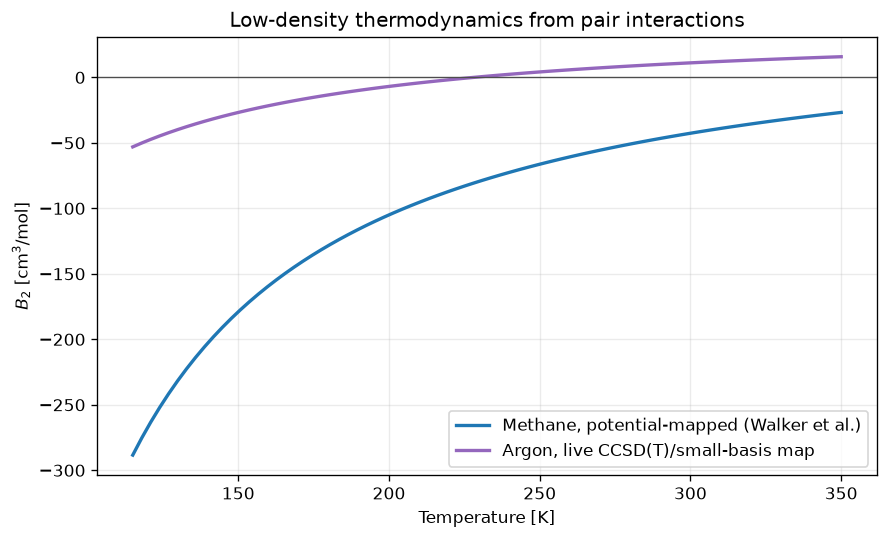

In [10]:
temperature_grid = np.linspace(115.0, 350.0, 80)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for parameters, color in [
    (methane_mapped, "tab:blue"),
    (ar_fundamental, "tab:purple"),
]:
    b2_values = [
        pair_second_virial(T, parameters)[0] * 1.0e6
        for T in temperature_grid
    ]
    ax.plot(
        temperature_grid,
        b2_values,
        color=color,
        linewidth=2,
        label=parameters["name"],
    )
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Temperature [K]",
    ylabel=r"$B_2$ [cm$^3$/mol]",
    title="Low-density thermodynamics from pair interactions",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 9. Transparent NVT molecular simulation

The next cell runs a small canonical Metropolis simulation of single Mie sites in reduced units. It is intentionally readable: periodic boundaries, minimum-image distances, single-particle moves, and the Metropolis criterion are all visible.

This is a numerical checkpoint, not a replacement for a production simulator. Use FEASST for Gibbs-ensemble VLE, transition-matrix/flat-histogram sampling, mixture moves, finite-size studies, and reproducible long runs.


In [11]:
def reduced_mie_energy(r_reduced, lambda_r, lambda_a=6.0):
    r = np.asarray(r_reduced, dtype=float)
    return mie_constant(lambda_r, lambda_a) * (
        r ** (-lambda_r) - r ** (-lambda_a)
    )


def minimum_image(delta, box_length):
    return delta - box_length * np.rint(delta / box_length)


def particle_energy(
    particle_index, trial_position, positions, box_length,
    cutoff, lambda_r, lambda_a
):
    displacement = minimum_image(
        trial_position - positions, box_length
    )
    distances = np.linalg.norm(displacement, axis=1)
    mask = (
        (np.arange(len(positions)) != particle_index)
        & (distances < cutoff)
    )
    if not np.any(mask):
        return 0.0
    shift = reduced_mie_energy(
        cutoff, lambda_r, lambda_a
    )
    return float(
        np.sum(
            reduced_mie_energy(
                distances[mask], lambda_r, lambda_a
            )
            - shift
        )
    )


def total_reduced_energy(
    positions, box_length, cutoff, lambda_r, lambda_a
):
    energy = 0.0
    for index in range(len(positions)):
        energy += particle_energy(
            index,
            positions[index],
            positions,
            box_length,
            cutoff,
            lambda_r,
            lambda_a,
        )
    return 0.5 * energy


def run_reference_mc(
    n_particles=64,
    reduced_temperature=1.5,
    reduced_density=0.30,
    sweeps=500,
    max_displacement=0.18,
    seed=4921,
):
    rng = np.random.default_rng(seed)
    box_length = (n_particles / reduced_density) ** (1.0 / 3.0)
    side = math.ceil(n_particles ** (1.0 / 3.0))
    lattice = np.linspace(
        0.0, box_length, side, endpoint=False
    ) + box_length / (2.0 * side)
    positions = np.array(
        np.meshgrid(lattice, lattice, lattice)
    ).reshape(3, -1).T[:n_particles].copy()
    cutoff = min(3.5, box_length / 2.0)
    lambda_r = methane_mapped["lambda_r"]
    lambda_a = methane_mapped["lambda_a"]

    accepted = 0
    attempted = 0
    history = []
    for sweep in range(sweeps):
        for particle_index in rng.permutation(n_particles):
            old_position = positions[particle_index].copy()
            old_energy = particle_energy(
                particle_index,
                old_position,
                positions,
                box_length,
                cutoff,
                lambda_r,
                lambda_a,
            )
            trial_position = (
                old_position
                + rng.uniform(
                    -max_displacement,
                    max_displacement,
                    size=3,
                )
            ) % box_length
            new_energy = particle_energy(
                particle_index,
                trial_position,
                positions,
                box_length,
                cutoff,
                lambda_r,
                lambda_a,
            )
            delta_energy = new_energy - old_energy
            attempted += 1
            if (
                delta_energy <= 0.0
                or rng.random()
                < np.exp(-delta_energy / reduced_temperature)
            ):
                positions[particle_index] = trial_position
                accepted += 1

        if sweep % 5 == 0 or sweep == sweeps - 1:
            history.append(
                total_reduced_energy(
                    positions,
                    box_length,
                    cutoff,
                    lambda_r,
                    lambda_a,
                )
                / n_particles
            )

    return {
        "positions": positions,
        "box_length": box_length,
        "cutoff": cutoff,
        "acceptance": accepted / attempted,
        "energy_history": np.asarray(history),
        "temperature": reduced_temperature,
        "density": reduced_density,
    }


mc_result = run_reference_mc()
final_energy = total_reduced_energy(
    mc_result["positions"],
    mc_result["box_length"],
    mc_result["cutoff"],
    methane_mapped["lambda_r"],
    methane_mapped["lambda_a"],
) / len(mc_result["positions"])
assert np.isclose(final_energy, mc_result["energy_history"][-1])
print(
    f"Acceptance = {mc_result['acceptance']:.3f}; "
    f"final U/(N epsilon) = {final_energy:.3f}"
)


Acceptance = 0.717; final U/(N epsilon) = -1.739


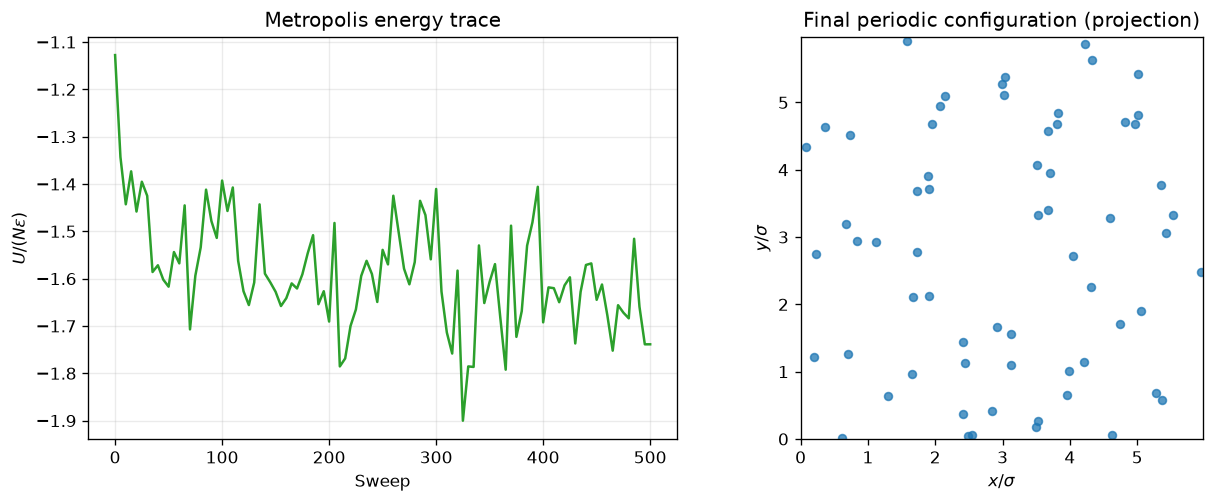

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(
    np.arange(len(mc_result["energy_history"])) * 5,
    mc_result["energy_history"],
    color="tab:green",
)
axes[0].set(
    xlabel="Sweep",
    ylabel=r"$U/(N\epsilon)$",
    title="Metropolis energy trace",
)
axes[0].grid(alpha=0.25)

axes[1].scatter(
    mc_result["positions"][:, 0],
    mc_result["positions"][:, 1],
    s=22,
    alpha=0.75,
    color="tab:blue",
)
axes[1].set(
    xlim=(0, mc_result["box_length"]),
    ylim=(0, mc_result["box_length"]),
    xlabel=r"$x/\sigma$",
    ylabel=r"$y/\sigma$",
    title="Final periodic configuration (projection)",
    aspect="equal",
)
plt.tight_layout()
plt.show()


### FEASST production hand-off

FEASST already provides SAFT-based Mie CO$_2$/N$_2$, Gibbs-ensemble, Mayer-sampling, and flat-histogram tutorials. The following machine-readable block is the parameter provenance record to translate into a FEASST particle/model input. A production study must additionally define cutoffs and long-range corrections, ensemble, system size, equilibration, uncertainty estimator, and random seeds.


In [13]:
feasst_handoff = {
    "source": "Walker et al. potential mapping, DOI 10.1063/5.0087125",
    "species": "methane",
    "sites_per_molecule": 1,
    "potential": "Mie",
    "sigma_angstrom": methane_mapped["sigma_angstrom"],
    "epsilon_over_k_K": methane_mapped["epsilon_over_k"],
    "lambda_r": methane_mapped["lambda_r"],
    "lambda_a": methane_mapped["lambda_a"],
    "recommended_workflow": [
        "Mayer sampling / B2 regression test",
        "NVT finite-size and cutoff study",
        "Gibbs or flat-histogram VLE",
        "mixture cross-parameter validation",
    ],
}
print(json.dumps(feasst_handoff, indent=2))


{
  "source": "Walker et al. potential mapping, DOI 10.1063/5.0087125",
  "species": "methane",
  "sites_per_molecule": 1,
  "potential": "Mie",
  "sigma_angstrom": 3.7592,
  "epsilon_over_k_K": 170.13,
  "lambda_r": 14.44,
  "lambda_a": 6.0,
  "recommended_workflow": [
    "Mayer sampling / B2 regression test",
    "NVT finite-size and cutoff study",
    "Gibbs or flat-histogram VLE",
    "mixture cross-parameter validation"
  ]
}


## 10. Independent SAFT-VR Mie validation with teqp

teqp provides a separately implemented SAFT-VR Mie residual Helmholtz model. We use it to calculate critical points and isothermal pressures. Experimental critical constants are included only as **benchmarks**; they are never passed to the mapping optimizer.

The expected pattern is informative:

- the live small-basis argon map exposes the electronic-structure error;
- an established argon SAFT set is close to the experimental critical point;
- the directly potential-mapped methane set is predictive rather than PVT-regressed;
- the standard NeqSim/Lafitte methane set was designed for bulk-fluid performance.


In [14]:
def critical_from_teqp(parameters, temperature_guess, density_guess):
    model = make_teqp_model(parameters)
    critical_temperature, critical_density = (
        model.solve_pure_critical(
            temperature_guess, density_guess
        )
    )
    z = np.array([1.0])
    critical_z = 1.0 + float(
        model.get_Ar01(
            critical_temperature, critical_density, z
        )
    )
    critical_pressure_bar = (
        critical_density
        * R
        * critical_temperature
        * critical_z
        / 1.0e5
    )
    return (
        float(critical_temperature),
        float(critical_pressure_bar),
        float(critical_density),
    )


critical_cases = [
    (
        ar_fundamental,
        110.0,
        11000.0,
        150.687,
        48.63,
        "Argon experiment",
    ),
    (
        argon_lafitte,
        150.0,
        12500.0,
        150.687,
        48.63,
        "Argon experiment",
    ),
    (
        methane_mapped,
        195.0,
        10000.0,
        190.564,
        45.99,
        "Methane experiment",
    ),
    (
        methane_neqsim,
        190.0,
        10000.0,
        190.564,
        45.99,
        "Methane experiment",
    ),
]
critical_rows = []
for (
    parameters,
    temperature_guess,
    density_guess,
    experimental_temperature,
    experimental_pressure,
    benchmark,
) in critical_cases:
    tc, pc, rhoc = critical_from_teqp(
        parameters, temperature_guess, density_guess
    )
    critical_rows.append(
        {
            "Parameter set": parameters["name"],
            "Tc [K]": tc,
            "Pc [bar]": pc,
            "rhoc [mol/m3]": rhoc,
            "Tc error [%]": (
                tc / experimental_temperature - 1.0
            ) * 100.0,
            "Pc error [%]": (
                pc / experimental_pressure - 1.0
            ) * 100.0,
            "Benchmark": benchmark,
        }
    )
critical_table = pd.DataFrame(critical_rows)
display(critical_table.round(3))


,Parameter set,Tc [K],Pc [bar],rhoc [mol/m3],Tc error [%],Pc error [%],Benchmark
0,"Argon, live CCSD(T)/small-basis map",85.449,24.003,10103.035,-43.294,-50.643,Argon experiment
1,"Argon, established SAFT-VR Mie set",153.983,53.755,12680.893,2.187,10.539,Argon experiment
2,"Methane, potential-mapped (Walker et al.)",201.723,52.698,9609.981,5.856,14.586,Methane experiment
3,"Methane, NeqSim/Lafitte parameter set",195.155,51.320,9595.134,2.409,11.589,Methane experiment


## 11. Inject the parameters into NeqSim

NeqSim stores SAFT-VR Mie parameters on every component in every phase. Length must be passed in metres and energy as $\epsilon/k_B$ in kelvin. The helper below performs the unit conversion and updates all phase objects before the flash.


In [15]:
def build_neqsim_saft_methane(
    temperature_k, pressure_bar, parameters
):
    system = jneqsim.thermo.system.SystemSAFTVRMie(
        temperature_k, pressure_bar
    )
    system.addComponent("methane", 1.0)
    for phase_index in range(
        int(system.getMaxNumberOfPhases())
    ):
        component = (
            system.getPhase(phase_index)
            .getComponent("methane")
        )
        component.setmSAFTVRMie(parameters["m"])
        component.setSigmaSAFTVRMie(
            parameters["sigma_angstrom"] * ANGSTROM_TO_M
        )
        component.setEpsikSAFTVRMie(
            parameters["epsilon_over_k"]
        )
        component.setLambdaRSAFTVRMie(
            parameters["lambda_r"]
        )
        component.setLambdaASAFTVRMie(
            parameters["lambda_a"]
        )
    operations = (
        jneqsim.thermodynamicoperations
        .ThermodynamicOperations(system)
    )
    operations.TPflash()
    system.initProperties()
    return system


audit_system = build_neqsim_saft_methane(
    300.0, 30.0, methane_mapped
)
audit_component = (
    audit_system.getPhase(0).getComponent("methane")
)
injected_audit = pd.Series(
    {
        "m [-]": float(audit_component.getmSAFTVRMie()),
        "sigma [Å]": float(
            audit_component.getSigmaSAFTVRMie()
        )
        / ANGSTROM_TO_M,
        "epsilon/kB [K]": float(
            audit_component.getEpsikSAFTVRMie()
        ),
        "lambda_r [-]": float(
            audit_component.getLambdaRSAFTVRMie()
        ),
        "lambda_a [-]": float(
            audit_component.getLambdaASAFTVRMie()
        ),
    },
    name="Read back from NeqSim",
)
display(injected_audit)


m [-]               1.0000
sigma [Å]           3.7592
epsilon/kB [K]    170.1300
lambda_r [-]       14.4400
lambda_a [-]        6.0000
Name: Read back from NeqSim, dtype: float64

## 12. Cross-implementation pressure test

At $T=300$ K we solve the teqp pressure equation for molar density and compare its compressibility factor with NeqSim at the same pressure:

$$
P=\rho RTZ,\qquad Z=1+A_{01}^{r}.
$$

Agreement here is a strong implementation check because the parameter source and state points are identical while the software paths are independent.


In [16]:
def teqp_density_at_pressure(
    model, temperature_k, pressure_bar
):
    target_pressure = pressure_bar * 1.0e5
    composition = np.array([1.0])

    def pressure_residual(molar_density):
        z_factor = 1.0 + float(
            model.get_Ar01(
                temperature_k,
                molar_density,
                composition,
            )
        )
        return (
            molar_density * R * temperature_k * z_factor
            - target_pressure
        )

    density_scan = np.geomspace(1.0e-9, 5.0e4, 600)
    residuals = [
        pressure_residual(rho) for rho in density_scan
    ]
    for lower, upper, f_lower, f_upper in zip(
        density_scan[:-1],
        density_scan[1:],
        residuals[:-1],
        residuals[1:],
    ):
        if f_lower * f_upper <= 0.0:
            return brentq(
                pressure_residual, lower, upper
            )
    raise RuntimeError("No gas-density root was bracketed")


comparison_pressures = np.array(
    [1.0, 10.0, 30.0, 60.0, 100.0]
)
solver_rows = []
for pressure_bar in comparison_pressures:
    teqp_density = teqp_density_at_pressure(
        methane_teqp, 300.0, pressure_bar
    )
    teqp_z = 1.0 + float(
        methane_teqp.get_Ar01(
            300.0, teqp_density, np.array([1.0])
        )
    )
    neqsim_system = build_neqsim_saft_methane(
        300.0, pressure_bar, methane_mapped
    )
    neqsim_z = float(neqsim_system.getZ())
    solver_rows.append(
        {
            "P [bar]": pressure_bar,
            "teqp rho [mol/m3]": teqp_density,
            "teqp Z [-]": teqp_z,
            "NeqSim Z [-]": neqsim_z,
            "relative Z difference [%]": (
                neqsim_z / teqp_z - 1.0
            ) * 100.0,
        }
    )
solver_table = pd.DataFrame(solver_rows)
display(solver_table.round(6))


,P [bar],teqp rho [mol/m3],teqp Z [-],NeqSim Z [-],relative Z difference [%]
0,1.0,40.157628,0.998335,0.998335,-0.000024
1,10.0,407.675101,0.983400,0.983398,-0.000240
2,30.0,1265.299272,0.950545,0.950538,-0.000734
3,60.0,2664.561987,0.902755,0.902742,-0.001464
4,100.0,4733.430054,0.846971,0.846954,-0.001993


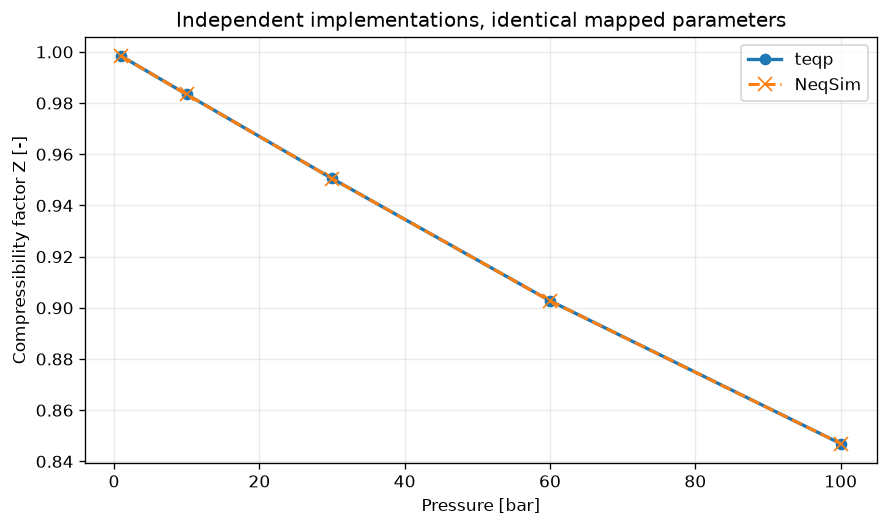

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    solver_table["P [bar]"],
    solver_table["teqp Z [-]"],
    "o-",
    linewidth=2,
    label="teqp",
)
ax.plot(
    solver_table["P [bar]"],
    solver_table["NeqSim Z [-]"],
    "x--",
    linewidth=1.8,
    markersize=8,
    label="NeqSim",
)
ax.set(
    xlabel="Pressure [bar]",
    ylabel="Compressibility factor Z [-]",
    title="Independent implementations, identical mapped parameters",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 13. Engineering propagation: methane compression

A 1 kg/s methane stream is compressed from 30 to 100 bara at 300 K with 75% isentropic efficiency. We compare the potential-mapped methane parameters with NeqSim's standard SAFT-VR Mie methane set. This is a sensitivity study, not a claim that the potential-mapped set is automatically superior for process design.


In [18]:
def run_compressor(parameters):
    fluid = build_neqsim_saft_methane(
        300.0, 30.0, parameters
    )
    inlet = jneqsim.process.equipment.stream.Stream(
        f"inlet-{parameters['name']}", fluid
    )
    inlet.setFlowRate(1.0, "kg/sec")
    inlet.run()

    compressor = (
        jneqsim.process.equipment.compressor.Compressor(
            f"compressor-{parameters['name']}", inlet
        )
    )
    compressor.setOutletPressure(100.0, "bara")
    compressor.setIsentropicEfficiency(0.75)
    compressor.run()
    outlet = compressor.getOutletStream()
    return {
        "Parameter set": parameters["name"],
        "Inlet density [kg/m3]": float(
            inlet.getFluid().getDensity("kg/m3")
        ),
        "Power [kW]": float(
            compressor.getPower("kW")
        ),
        "Outlet temperature [degC]": float(
            outlet.getTemperature("C")
        ),
    }


compressor_table = pd.DataFrame(
    [
        run_compressor(methane_neqsim),
        run_compressor(methane_mapped),
    ]
)
display(compressor_table.round(4))

power_change = (
    compressor_table.loc[1, "Power [kW]"]
    / compressor_table.loc[0, "Power [kW]"]
    - 1.0
) * 100.0
print(
    "Mapped-versus-standard compressor-power change: "
    f"{power_change:+.3f}%"
)


Mapped-versus-standard compressor-power change: -0.255%


,Parameter set,Inlet density [kg/m3],Power [kW],Outlet temperature [degC]
0,"Methane, NeqSim/Lafitte parameter set",20.2318,277.0882,149.2488
1,"Methane, potential-mapped (Walker et al.)",20.2993,276.3803,149.4329


## 14. Propagate mapping uncertainty

We resample the live quantum-curve residuals, refit the three Mie parameters, and solve each resulting argon critical point with teqp. This bootstrap represents **sampling and fit uncertainty conditional on the chosen CCSD(T)/aug-cc-pVDZ model**. It does not include the much larger basis-set, many-body, or model-form errors.


,Quantity,Median,2.5%,97.5%
0,sigma [Å],3.6581,3.6340,3.6768
1,epsilon/kB [K],59.9594,54.1910,68.5342
2,lambda_r [-],11.0573,10.6111,11.5187
3,predicted Tc [K],82.3188,73.7088,95.9576


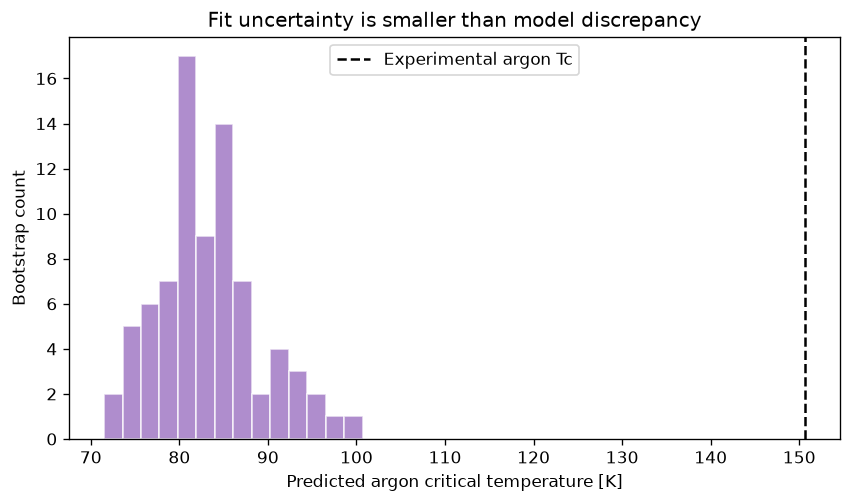

In [19]:
fitted_values = mie_u_over_k(
    ar_distances, sigma_fit, epsilon_fit, lambda_r_fit, 6.0
)
fit_residuals = ar_interaction_k - fitted_values
bootstrap_parameters = []
bootstrap_tc = []

for _ in range(80):
    synthetic_energies = (
        fitted_values
        + RNG.choice(
            fit_residuals,
            size=len(fit_residuals),
            replace=True,
        )
    )
    bootstrap_fit = least_squares(
        weighted_residual,
        x0=fit.x,
        bounds=(
            np.array([2.5, 10.0, 7.0]),
            np.array([4.5, 500.0, 40.0]),
        ),
        args=(ar_distances, synthetic_energies),
    )
    bootstrap_parameter_set = {
        "name": "Argon bootstrap",
        "m": 1.0,
        "sigma_angstrom": bootstrap_fit.x[0],
        "epsilon_over_k": bootstrap_fit.x[1],
        "lambda_r": bootstrap_fit.x[2],
        "lambda_a": 6.0,
    }
    tc, _, _ = critical_from_teqp(
        bootstrap_parameter_set, 110.0, 11000.0
    )
    bootstrap_parameters.append(bootstrap_fit.x)
    bootstrap_tc.append(tc)

bootstrap_parameters = np.asarray(bootstrap_parameters)
bootstrap_tc = np.asarray(bootstrap_tc)
uncertainty_summary = pd.DataFrame(
    {
        "Quantity": [
            "sigma [Å]",
            "epsilon/kB [K]",
            "lambda_r [-]",
            "predicted Tc [K]",
        ],
        "Median": [
            *np.median(bootstrap_parameters, axis=0),
            np.median(bootstrap_tc),
        ],
        "2.5%": [
            *np.percentile(
                bootstrap_parameters, 2.5, axis=0
            ),
            np.percentile(bootstrap_tc, 2.5),
        ],
        "97.5%": [
            *np.percentile(
                bootstrap_parameters, 97.5, axis=0
            ),
            np.percentile(bootstrap_tc, 97.5),
        ],
    }
)
display(uncertainty_summary.round(4))

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.hist(
    bootstrap_tc,
    bins=14,
    color="tab:purple",
    alpha=0.75,
    edgecolor="white",
)
ax.axvline(
    150.687,
    color="black",
    linestyle="--",
    label="Experimental argon Tc",
)
ax.set(
    xlabel="Predicted argon critical temperature [K]",
    ylabel="Bootstrap count",
    title="Fit uncertainty is smaller than model discrepancy",
)
ax.legend()
plt.tight_layout()
plt.show()


## 15. What must be added for molecules and mixtures?

| Missing layer | Fundamental route | Open-source implementation path |
|---|---|---|
| Molecular orientation | Sample multiple dimer orientations and coarse-grain the anisotropic surface | PySCF plus SciPy; FEASST anisotropic/tabulated potentials |
| Chain length $m$ | Map molecular shape or optimize against molecular-simulation structural observables | teqp/NeqSim sensitivity plus FEASST |
| Association | Calculate hydrogen-bond energy/volume and site topology | PySCF; teqp association models; NeqSim association setters |
| Unlike interactions | Compute unlike dimers rather than assuming one combining rule | PySCF; MAPSCI/DESPASITO or custom optimization |
| Many-body effects | Three-body electronic calculations, polarizable models, or effective corrections | PySCF; FEASST custom/many-body models |
| Nuclear quantum effects | Feynman-Hibbs or path-integral correction where significant | Preprocessing or a specialized quantum simulator |
| Production VLE | Gibbs/flat-histogram simulation, size scaling, and uncertainty | FEASST SAFT-based Mie tutorials |

A defensible mixture workflow should keep pure-component provenance, unlike-pair calculations, combining rules, and any regression targets in separate records. That makes it clear which parameters are fundamental, transferred, or empirically calibrated.


## 16. Automated verification summary

These checks cover units, potential normalization, quantum-curve shape, Monte Carlo bookkeeping, independent EOS agreement, and reasonable critical-point benchmarks. Passing them verifies the workflow—not the completeness of the underlying molecular physics.


In [20]:
max_solver_difference = float(
    np.max(
        np.abs(
            solver_table["relative Z difference [%]"]
        )
    )
)
checks = {
    "Mie minimum equals -epsilon": all(
        abs(
            mie_u_over_k(
                mie_minimum(
                    p["sigma_angstrom"],
                    p["lambda_r"],
                    p["lambda_a"],
                ),
                p["sigma_angstrom"],
                p["epsilon_over_k"],
                p["lambda_r"],
                p["lambda_a"],
            )
            + p["epsilon_over_k"]
        )
        < 1.0e-8
        for p in (
            methane_mapped,
            methane_neqsim,
            ar_fundamental,
        )
    ),
    "Quantum curve has repulsion and attraction": (
        ar_interaction_k[0] > 0.0
        and np.min(ar_interaction_k) < 0.0
    ),
    "Mapped parameters remain inside physical bounds": (
        2.5 < sigma_fit < 4.5
        and 10.0 < epsilon_fit < 500.0
        and 7.0 < lambda_r_fit < 40.0
    ),
    "MC acceptance is informative": (
        0.15 < mc_result["acceptance"] < 0.80
    ),
    "NeqSim and teqp Z agree within 0.01%": (
        max_solver_difference < 0.01
    ),
    "Established argon set predicts Tc within 5%": (
        abs(critical_table.loc[1, "Tc error [%]"]) < 5.0
    ),
    "Mapped methane predicts Tc within 10%": (
        abs(critical_table.loc[2, "Tc error [%]"]) < 10.0
    ),
    "Bootstrap produced finite critical points": bool(
        np.all(np.isfinite(bootstrap_tc))
    ),
}
verification_table = pd.DataFrame(
    {
        "Check": list(checks),
        "Status": [
            "PASS" if result else "FAIL"
            for result in checks.values()
        ],
    }
)
display(verification_table)
assert all(checks.values()), checks
print("All executable verification checks passed.")


All executable verification checks passed.


,Check,Status
0,Mie minimum equals -epsilon,PASS
1,Quantum curve has repulsion and attraction,PASS
2,Mapped parameters remain inside physical bounds,PASS
3,MC acceptance is informative,PASS
4,NeqSim and teqp Z agree within 0.01%,PASS
5,Established argon set predicts Tc within 5%,PASS
6,Mapped methane predicts Tc within 10%,PASS
7,Bootstrap produced finite critical points,PASS


## 17. Conclusions and recommended project sequence

1. **Use this notebook now** to teach and audit the complete parameter path.
2. **Upgrade the potential** to CCSD(T)/CBS or a published high-quality many-body surface.
3. **Validate low density first** with $B_2(T)$ and FEASST Mayer sampling.
4. **Validate coexistence next** with FEASST Gibbs/flat-histogram simulations and teqp.
5. **Only then propagate** the frozen, versioned parameters into NeqSim process models.
6. For associating molecules and mixtures, add orientation, sites, unlike-pair calculations, and explicit combining-rule provenance.

The central lesson is that SAFT-VR Mie parameters can be obtained from fundamental interaction models, but “fundamental” does not eliminate approximation. The electronic-structure level, coarse-graining choice, many-body treatment, EOS approximation, and process sensitivity must all be visible.


## 18. Exercises

1. Replace aug-cc-pVDZ with aug-cc-pVTZ and quantify the change in $\epsilon/k_B$ and predicted $T_c$.
2. Add more points around the zero crossing and potential minimum; repeat the bootstrap.
3. Compare $\lambda_r$ from least squares with a mapping based on the Barker-Henderson diameter.
4. Run the exported methane parameter set in FEASST and compare its Mayer-sampling $B_2$ with the direct quadrature.
5. Calculate unlike methane-argon dimer energies and compare a fitted cross potential with common combining rules.
6. Add a second NeqSim process state closer to the critical region and explain why sensitivity increases.


## 19. References and provenance

- Walker, A. et al., “On the development of coarse-grained models for molecular fluids from *ab initio* interaction potentials,” *Journal of Chemical Physics* **156**, 154106 (2022), [DOI: 10.1063/5.0087125](https://doi.org/10.1063/5.0087125).
- Lafitte, T. et al., “Accurate statistical associating fluid theory for chain molecules formed from Mie segments,” *Journal of Chemical Physics* **139**, 154504 (2013), [DOI: 10.1063/1.4819786](https://doi.org/10.1063/1.4819786).
- Sun, Q. et al., “Recent developments in the PySCF program package,” *Journal of Chemical Physics* **153**, 024109 (2020), [DOI: 10.1063/5.0006074](https://doi.org/10.1063/5.0006074).
- Hatch, H. W. et al., “Monte Carlo simulation of cylinders with short-range attractions,” *Journal of Chemical Physics* **142**, 164105 (2015); [FEASST documentation and tutorials](https://pages.nist.gov/feasst/).
- [teqp SAFT-VR Mie documentation](https://teqp.readthedocs.io/en/latest/models/SAFT-VR-Mie.html).
- [NeqSim source and documentation](https://github.com/equinor/neqsim).
- Experimental critical constants used as external checks: NIST Chemistry WebBook entries for [argon](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7440371&Mask=4) and [methane](https://webbook.nist.gov/cgi/cbook.cgi?ID=C74828&Mask=4).

Parameter provenance used in the engineering route:

- Potential-mapped methane: $\sigma=3.7592$ Å, $\epsilon/k_B=170.13$ K, $\lambda_r=14.440$, $\lambda_a=6$, $m=1$ (Walker *et al.*).
- NeqSim methane baseline read from NeqSim 3.16.0: $\sigma=3.7412$ Å, $\epsilon/k_B=153.36$ K, $\lambda_r=12.65$, $\lambda_a=6$, $m=1$.
